In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder 
from sklearn.feature_selection import SelectFromModel           

# Data Loading
Train-test split is 80/20

In [115]:
X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
y_train = pd.read_csv("../data/processed/y_train.csv", index_col=0)

X_test = pd.read_csv("../data/processed/X_test.csv", index_col=0)
y_test = pd.read_csv("../data/processed/y_test.csv", index_col=0)

In [116]:
# inspecting a sample
X_train.sample(5)

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Swallowing_Difficulty,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months
390,LC-0391,2017,2017-09-05,Europe,Turkey,77,Male,Former Smoker,12,28,...,No,No,NSCLC,Large Cell,Stage IV,8.7,Yes,Biopsy,Immunotherapy,11
504,LC-0505,2017,2017-01-05,Americas,Chile,53,Male,Current Smoker,22,8,...,Yes,No,NSCLC,Adenocarcinoma,Stage IV,7.4,Yes,Biopsy,Chemotherapy,10
1384,LC-1385,2022,2022-09-24,Western Pacific,Singapore,57,Male,Never Smoked,0,0,...,No,No,NSCLC,Large Cell,Stage I,1.3,No,LDCT Screening,Surgery,60
737,LC-0738,2015,2015-06-13,Europe,Sweden,60,Female,Never Smoked,0,0,...,No,No,NSCLC,Adenocarcinoma,Stage III,6.5,Yes,CT Scan,Targeted Therapy,16
486,LC-0487,2018,2018-02-22,Western Pacific,Vietnam,76,Male,Never Smoked,0,0,...,No,No,NSCLC,Adenocarcinoma,Stage II,4.1,No,MRI,Immunotherapy,34


In [ ]:
# defining numeric, categorical and binary columns
num_cols = ['Age', 'BMI', 'Pack_Years', 'Symptom_Count', 'Risk_Count']

cat_cols = ['Smoking_Status',
            'Air_Pollution_Exposure', 'Alcohol_Use', 'Exercise_Frequency',
             'Genetic_Mutation', 'NSCLC_Subtype', 
             'Diagnosis_Method', 'Treatment']

binary_cols = ['Gender', 'Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
                'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
                'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
                'Finger_Clubbing', 'Metastasis', 'Cancer_Type',]


In [ ]:
def clean_data(X):
    """
    Drops columns with no predictive value:
    - Patient_ID: only an identifier
    - Diagnosis_Year/Date: redundant temporal info
    - Survival_Months: target leakage. 
    """
    X = X.drop(['Patient_ID', 'Diagnosis_Year', 
                              'Diagnosis_Date', 'Survival_Months'], axis=1)
    return X

In [ ]:
# removing columns again to reduce correlation instead of using PCA
def engineer_X(X):

    # adding pack_years as a feature (a standard clinical metric)
    X['Pack_Years'] = (X['Cigarettes_Per_Day'] / 20) * X['Years_Smoking']

    # changing cancer stage to ordinal values
    stage_map = {'Stage I': 1,
                 'Stage II': 2,
                 'Stage III': 3,
                 'Stage IV': 4}
    X['Cancer_Stage_Numeric'] = X['Cancer_Stage'].map(stage_map)

    # changing binary values to 1 and 0
    binary_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History', 'Coughing','Shortness_of_Breath', 
                'Chest_Pain', 'Coughing_Blood', 'Fatigue', 'Weight_Loss', 
                'Wheezing', 'Recurrent_Infections', 'Swallowing_Difficulty', 
                'Finger_Clubbing', 'Metastasis']

    X[binary_cols] = X[binary_cols].eq("Yes").astype(int)

    # converting gender values
    X['Gender'] = X['Gender'].eq("Male").astype(int)
    
    # converting cancer types
    X['Cancer_Type'] = X['Cancer_Type'].eq("NSCLC").astype(int)

    # creating a count column for symptoms and risk
    symptom_cols = ['Coughing','Shortness_of_Breath', 'Chest_Pain', 
                    'Coughing_Blood', 'Fatigue', 'Weight_Loss', 'Wheezing', 
                    'Recurrent_Infections', 'Swallowing_Difficulty', 
                    'Finger_Clubbing', 'Metastasis']
    X['Symptom_Count'] = X[symptom_cols].sum(axis=1).astype(int)

    risk_cols = ['Secondhand_Smoke', 'Family_History', 'Occupational_Hazard',
                'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
                'Previous_Cancer_History']
    X['Risk_Count'] = X[risk_cols].sum(axis=1).astype(int)

    X = X.drop(columns=['Cigarettes_Per_Day', 'Years_Smoking', 
                        'Cancer_Stage', 'Tumor_Size_cm', 'Country',
                        'WHO_Region'])

    return X


In [ ]:
def bool_target(y):
    """Converts target column from 'Yes'/'No' to 1/0."""
    y['Survived'] = y['Survived'].eq("Yes").astype(int)
    return y

In [ ]:
# Apply cleaning, feature engineering, and target encoding to both splits.
X_train = engineer_X(clean_data(X_train))
X_test = engineer_X(clean_data(X_test))

y_train = bool_target(y_train)
y_test = bool_target(y_test)

# Baseline Model: RandomForest without hypertuning

Preprocessing Config                                                  
  Column groups used by the `ColumnTransformer`:                          
  - `num_cols`: continuous features scaled with `StandardScaler`
  - `cat_cols`: nominal features encoded with `OneHotEncoder`
  - `binary_cols`: already-encoded 0/1 features passed through unchanged
  - `Cancer_Stage_Numeric`: ordinal feature encoded with `OrdinalEncoder` 
  to preserve stage order

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ord', OrdinalEncoder(categories=[[1, 2, 3, 4]]), ['Cancer_Stage_Numeric']), 
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('bin', 'passthrough', binary_cols)
])

rf = RandomForestClassifier(n_estimators=100,
                            class_weight='balanced', # to compensate for resampling
                            random_state=0,
                            n_jobs=-1)

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

In [130]:
model_rf.fit(X_train, y_train.values.ravel())
y_pred = model_rf.predict(X_test)

print(f"Random Forests Performance:\n")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, 
                                      model_rf.predict_proba(X_test)[:, 1]):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Random Forests Performance:

F1 Score: 0.6726
ROC-AUC Score: 0.8341
Precision: 0.6696
Recall: 0.6757


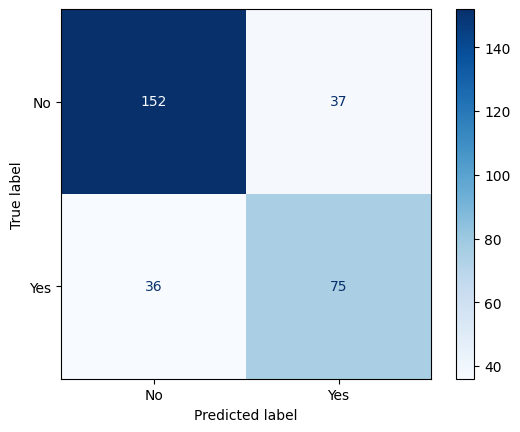

In [131]:
# Confusion Matrix
cm = confusion_matrix(y_test, 
                      y_pred, 
                      labels=[0, 1])

disp = ConfusionMatrixDisplay(cm, 
                              display_labels=['No', 'Yes']).plot(cmap='Blues')


# feature importance

In [125]:
feature_names = model_rf.named_steps['preprocessor'].get_feature_names_out()
feature_names

array(['num__Age', 'num__BMI', 'num__Pack_Years', 'num__Symptom_Count',
       'num__Risk_Count', 'ord__Cancer_Stage_Numeric',
       'cat__Smoking_Status_Current Smoker',
       'cat__Smoking_Status_Former Smoker',
       'cat__Smoking_Status_Never Smoked',
       'cat__Air_Pollution_Exposure_High',
       'cat__Air_Pollution_Exposure_Low',
       'cat__Air_Pollution_Exposure_Moderate', 'cat__Alcohol_Use_Heavy',
       'cat__Alcohol_Use_Moderate', 'cat__Alcohol_Use_No Alcohol',
       'cat__Exercise_Frequency_High', 'cat__Exercise_Frequency_Low',
       'cat__Exercise_Frequency_Moderate', 'cat__Genetic_Mutation_ALK',
       'cat__Genetic_Mutation_BRAF', 'cat__Genetic_Mutation_EGFR',
       'cat__Genetic_Mutation_HER2', 'cat__Genetic_Mutation_KRAS',
       'cat__Genetic_Mutation_MET', 'cat__Genetic_Mutation_No Mutation',
       'cat__Genetic_Mutation_RET', 'cat__Genetic_Mutation_ROS1',
       'cat__Genetic_Mutation_TP53', 'cat__NSCLC_Subtype_Adenocarcinoma',
       'cat__NSCLC_Subtype_

In [126]:
# strip prefixes like "num__", "cat__", "bin__", "ord__"
feature_names = [name.split('__', 1)[-1] for name in feature_names]
feature_names

['Age',
 'BMI',
 'Pack_Years',
 'Symptom_Count',
 'Risk_Count',
 'Cancer_Stage_Numeric',
 'Smoking_Status_Current Smoker',
 'Smoking_Status_Former Smoker',
 'Smoking_Status_Never Smoked',
 'Air_Pollution_Exposure_High',
 'Air_Pollution_Exposure_Low',
 'Air_Pollution_Exposure_Moderate',
 'Alcohol_Use_Heavy',
 'Alcohol_Use_Moderate',
 'Alcohol_Use_No Alcohol',
 'Exercise_Frequency_High',
 'Exercise_Frequency_Low',
 'Exercise_Frequency_Moderate',
 'Genetic_Mutation_ALK',
 'Genetic_Mutation_BRAF',
 'Genetic_Mutation_EGFR',
 'Genetic_Mutation_HER2',
 'Genetic_Mutation_KRAS',
 'Genetic_Mutation_MET',
 'Genetic_Mutation_No Mutation',
 'Genetic_Mutation_RET',
 'Genetic_Mutation_ROS1',
 'Genetic_Mutation_TP53',
 'NSCLC_Subtype_Adenocarcinoma',
 'NSCLC_Subtype_Large Cell',
 'NSCLC_Subtype_Not Applicable',
 'NSCLC_Subtype_Squamous Cell',
 'Diagnosis_Method_Biopsy',
 'Diagnosis_Method_Bronchoscopy',
 'Diagnosis_Method_CT Scan',
 'Diagnosis_Method_Chest X-Ray',
 'Diagnosis_Method_LDCT Screening',
 

In [127]:
importances = model_rf.named_steps['model'].feature_importances_

# sort descending
idx = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in idx]  
sorted_importances = importances[idx]

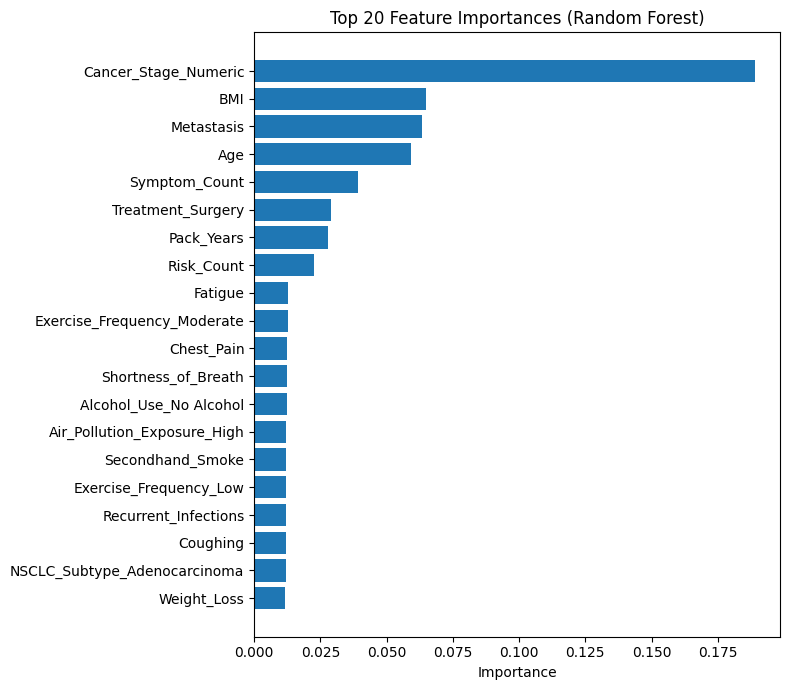

In [128]:
# plot top 20
n = 20
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(sorted_names[:n][::-1],
sorted_importances[:n][::-1])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances (Random Forest)')

plt.tight_layout()
plt.show()

In [129]:
sorted_names

['Cancer_Stage_Numeric',
 'BMI',
 'Metastasis',
 'Age',
 'Symptom_Count',
 'Treatment_Surgery',
 'Pack_Years',
 'Risk_Count',
 'Fatigue',
 'Exercise_Frequency_Moderate',
 'Chest_Pain',
 'Shortness_of_Breath',
 'Alcohol_Use_No Alcohol',
 'Air_Pollution_Exposure_High',
 'Secondhand_Smoke',
 'Exercise_Frequency_Low',
 'Recurrent_Infections',
 'Coughing',
 'NSCLC_Subtype_Adenocarcinoma',
 'Weight_Loss',
 'Family_History',
 'Gender',
 'Air_Pollution_Exposure_Moderate',
 'Treatment_Chemo + Radiation',
 'Alcohol_Use_Moderate',
 'Treatment_Surgery + Chemotherapy',
 'Genetic_Mutation_No Mutation',
 'Occupational_Hazard',
 'Treatment_Chemotherapy',
 'Diagnosis_Method_CT Scan',
 'Genetic_Mutation_ALK',
 'Diagnosis_Method_PET Scan',
 'Exercise_Frequency_High',
 'Diagnosis_Method_LDCT Screening',
 'NSCLC_Subtype_Squamous Cell',
 'Air_Pollution_Exposure_Low',
 'Wheezing',
 'Genetic_Mutation_EGFR',
 'Diagnosis_Method_Biopsy',
 'Treatment_Radiotherapy',
 'Coughing_Blood',
 'Alcohol_Use_Heavy',
 'Swall